# Molecular filtering: unwanted structures

## Aim
There are some substructures we prefer not to include into our library. We will learn about different types of such unwanted substructures and how to find, highlight and remove them with RDKit.

- Unwanted substructures
- Pan Assay Interference Compounds (PAINS)

## For more details
https://github.com/volkamerlab/teachopencadd/tree/master/teachopencadd/talktorials/T003_compound_unwanted_substructures

## Instructions
Replace XXX with the appropriate code

## Configuration

In [16]:
# Magic commands
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
# Imports
# 1. Standard library imports
from pathlib import Path
import sys
sys.path.append('../my_modules') # to tell where to find local modules

# 2. Third-party library imports
import pandas as pd
from rdkit import Chem
from rdkit.Chem import (
    Draw,
    PandasTools
)
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
PandasTools.RenderImagesInAllDataFrames(images=True) # to molecules as images in DataFrames
from rdkit.Chem.Draw import IPythonConsole # needed to show molecules
# from rdkit.Chem.Draw.MolDrawing import MolDrawing, DrawingOptions # only needed if modifying defaults
from tqdm.auto import tqdm

# 3. Local application imports
import kernel_infos

In [18]:
# Information about the kernel
kernel_infos.show_kernel_info()

=== Kernel Information ===
Python version: 3.14.0 (main, Oct  7 2025, 09:34:52) [Clang 17.0.0 (clang-1700.0.13.3)]
Executable: /Users/bourg/Enseignement/GSON/gson_sbc/.venv/bin/python3
Platform: macOS-15.7.2-arm64-arm-64bit-Mach-O
IPython version: 9.7.0


In [19]:
# Global variables
HERE = Path().resolve()
print(f'{HERE}')
ROOT = HERE.parent
print(f'{ROOT}')
DATA = ROOT / 'data'
print(f'{DATA}')

/Users/bourg/Enseignement/GSON/gson_sbc/notebooks
/Users/bourg/Enseignement/GSON/gson_sbc
/Users/bourg/Enseignement/GSON/gson_sbc/data


## Load previous data

In [20]:
# File to load
EGFR_compounds_lipinski_csv_path = DATA / "EGFR_compounds_lipinski.csv"

In [21]:
# Load in a dataframe
egfr_df = pd.read_csv(EGFR_compounds_lipinski_csv_path, index_col=0)
print(f"Dataframe shape: {egfr_df.shape}")
egfr_df.head(3)

Dataframe shape: (7153, 10)


,molecule_chembl_id,IC50,units,smiles,pIC50,MW,HBA,HBD,LogP,ro5_fulfilled
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,349.021459,3,1,5.2891,True
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,387.058239,5,1,4.9333,True
2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,343.043258,5,1,3.5969,True


In [22]:
# Drop descriptor (MW, HBA, HBD and LogP) columns
egfr_df.drop(columns=['MW', 'HBA', 'HBD', 'LogP'], inplace=True)
print(f"Dataframe shape: {egfr_df.shape}")
egfr_df.head(3)

Dataframe shape: (7153, 6)


,molecule_chembl_id,IC50,units,smiles,pIC50,ro5_fulfilled
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,True
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,True
2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,True


,molecule_chembl_id,IC50,units,smiles,pIC50,ro5_fulfilled,ROMol
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,True,
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,True,
2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,True,

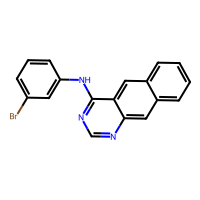
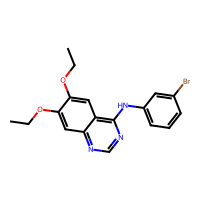
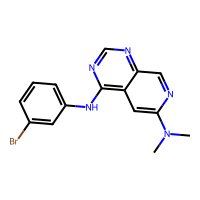

In [23]:
# Add molecule column: ROMol
PandasTools.AddMoleculeColumnToFrame(egfr_df, smilesCol='smiles')
egfr_df.head(3)

## Filter for PAINS using RDKit implemented solution

In [24]:
# Initialize the FilterCatalog class for PAINS 
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
catalog = FilterCatalog(params)

In [25]:
# Search for PAINS
# Initialize 2 lists
pains_l = list()
no_pains_l = list()

for index, row in tqdm(egfr_df.iterrows(), total = egfr_df.shape[0]):
    entry = catalog.GetFirstMatch(row['ROMol']) # Get the first matching PAINS
    if entry is not None:
        # store PAINS information as a dictionnary
        pains_l.append(
            {
                "ChEMBL_ID": row["molecule_chembl_id"],
                "rdkit_molecule": row['ROMol'],
                'pains': entry.GetDescription().capitalize()
            }
        )
    else:
        # Collect indices of molecules without PAINS
        no_pains_l.append(index)

100%|██████████████████████████████████████| 7153/7153 [00:10<00:00, 655.40it/s]


Number of compounds with a PAINS substructure: 575


,ChEMBL_ID,rdkit_molecule,pains
0,CHEMBL5271803,,Hzone_pyrrol(64)
1,CHEMBL5220645,,Anil_di_alk_g(9)
2,CHEMBL93032,,Catechol_a(92)

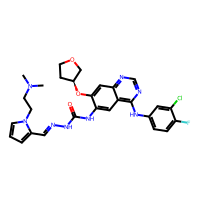
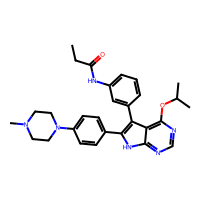
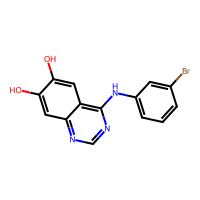

In [26]:
# Transform pains_l in a dataframe
pains_df = pd.DataFrame(pains_l)

# How many compounds ?
print(f"Number of compounds with a PAINS substructure: {pains_df.shape[0]}")

# Display the first 3 lignes of the dataframe
pains_df.head(3)

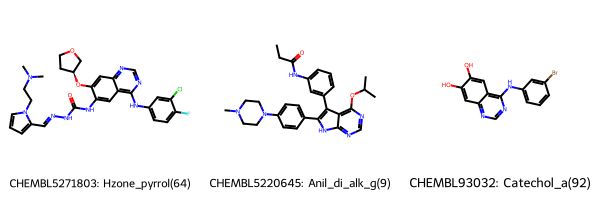

In [27]:
# Draw an image with the first 3 compounds and add the ChEML_ID and the name of the detected PAINS to the legend
Draw.MolsToGridImage(
    pains_df['rdkit_molecule'].head(3).to_list(),
    legends = [f"{id}: {name}" for id, name in zip(pains_df['ChEMBL_ID'], pains_df['pains'])]
)

In [28]:
# How many compounds without PAINS substructure ? (use the list of indices of such compounds)
print(f"Number of compounds without PAINS substructure: {egfr_df.loc[no_pains_l].shape[0]}")

Number of compounds without PAINS substructure: 6578


## Filter for BRENK unwanted substructures
BRENK substructures are now implemented in RDKit but use the provided list of the supporting information from Brenk _et al._ (https://doi.org/10.1002/cmdc.200700139
) as an external list to get the substructure matches manually

### Filtering

In [ ]:
# Brenk unwanted substructures file path
brenk_csv_path = DATA / 'unwanted_Brenk_substructures.csv'

In [ ]:
# Load the Brenk unwanted substructures in a dataframe
# Separator is a space character
brenk_df = pd.read_csv(brenk_csv_path, sep=' ')

In [ ]:
# How many structures
print(f'Number of Brenk unwanted substructures: {brenk_df.shape[0]}')

In [ ]:
# Head the dataframe
brenk_df.head(3)

In [ ]:
# Add a 'rdkit_molecule' column from its 'smarts' code to brenk_df
brenk_df['rdkit_molecule'] = brenk_df['smarts'].map(Chem.MolFromSmarts)

In [ ]:
# Draw an image with the first 3 molecules corresponding to the structure with their #name
n = 3
Draw.MolsToGridImage(
    molsPerRow = 3,
    mols = brenk_df.head(n)['rdkit_molecule'].tolist(),
    legends= brenk_df.head(n)['#name'].tolist()
)

In [ ]:
egfr_df.head(1)

In [ ]:
# Search egfr_df for unwanted substructures
brenk_l = list()
no_brenk_l = list()

for index, row in tqdm(egfr_df.iterrows(), total = egfr_df.shape[0]):
    match = False
    for _, substructure in brenk_df.iterrows():
        if row['ROMol'].HasSubstructMatch(substructure['rdkit_molecule']):
            brenk_l.append(
                {
                    'ChEMBL_ID': row['molecule_chembl_id'],
                    'rdkit_molecule': row['ROMol'],
                    'substructure': substructure['rdkit_molecule'],
                    'substructure_name': substructure['#name'],
                }                
            )
            match = True
    if not match:
        # Collect indices of molecules without Brenk substructure
        no_brenk_l.append(index)

In [ ]:
# Transform brenk_l in a dataframe
brenk_df = pd.DataFrame(brenk_l)

# How many compounds ?
print(f"Number of compounds with a Brenk substructure: {brenk_df.shape[0]}")

# Show the first 3 lignes of the dataframe
brenk_df.head(3)

In [ ]:
# How many compounds without Brenk substructure ? (use a "fancy indexing": a list indexation)
print(f"Number of compounds without Brenk substructure: {egfr_df.loc[no_brenk_l].shape[0]}")

### Highlight Brenk substructures in an image of the first 3 compounds containing a Brenk substructures

In [ ]:
# number of molecules to highlight
n=3

# list of molecules
mols = brenk_df.head(n)['rdkit_molecule'].tolist()

# list of atom lists
to_highlight = [row['rdkit_molecule'].GetSubstructMatch(row['substructure']) for _, row in brenk_df.head(n).iterrows()]

# list of legends
legends = brenk_df.head(n)['substructure_name'].tolist()

# image
Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(300, 300),
    highlightAtomLists=to_highlight,
    legends = legends
)

### Most frequent Brenk substructures

In [ ]:
# Define groups by "substructure_name"
groups = brenk_df.groupby("substructure_name")

# Compute group frequencies
group_frequencies = groups.size()

# Sort them
group_frequencies.sort_values(ascending=False, inplace=True)

# Print the n first frequencies
n = 10
group_frequencies.head(n)